In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.decomposition import PCA
from sklearn.ensemble import RandomForestClassifier
from sklearn.svm import SVC
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix
import pennylane as qml
import seaborn as sns
import kagglehub
import os
import zipfile
from kaggle.api.kaggle_api_extended import KaggleApi

In [5]:
csv_path = 'datasets/LI-Small_Trans.csv'

# Download if doesnt exist
if not os.path.exists(csv_path):
    print("Dataset no found. Downloading from Kaggle...")
    
    os.makedirs('datasets', exist_ok=True)
    
    # Autenticate and dowload only a specific file
    api = KaggleApi()
    api.authenticate()
    api.dataset_download_file(
        'ealtman2019/ibm-transactions-for-anti-money-laundering-aml',
        file_name='LI-Small_Trans.csv',
        path='datasets',
    )
    print("Descarga completada.")

df = pd.read_csv(csv_path)

print(df.info())

Dataset no found. Downloading from Kaggle...
Dataset URL: https://www.kaggle.com/datasets/ealtman2019/ibm-transactions-for-anti-money-laundering-aml
Descarga completada.
<class 'pandas.DataFrame'>
RangeIndex: 6924049 entries, 0 to 6924048
Data columns (total 11 columns):
 #   Column              Dtype  
---  ------              -----  
 0   Timestamp           str    
 1   From Bank           int64  
 2   Account             str    
 3   To Bank             int64  
 4   Account.1           str    
 5   Amount Received     float64
 6   Receiving Currency  str    
 7   Amount Paid         float64
 8   Payment Currency    str    
 9   Payment Format      str    
 10  Is Laundering       int64  
dtypes: float64(2), int64(3), str(6)
memory usage: 581.1 MB
None


In [42]:
print("\nClass Distribution (Is Laundering):")
print(df['Is Laundering'].value_counts(normalize=True) * 100)


Class Distribution (Is Laundering):
Is Laundering
0    99.948513
1     0.051487
Name: proportion, dtype: float64


# Data Preprocessing

In [43]:
df['Hour'] = pd.to_datetime(df['Timestamp']).dt.hour # Add column to detect suspicious transfer hours

columns_to_drop =['Timestamp', 'From Bank', 'Account', 'To Bank', 'Account.1']
df_clean = df.drop(columns=[col for col in columns_to_drop if col in df.columns])

# One-Hot Encode categorical variables
df_encoded = pd.get_dummies(df_clean, drop_first=True)

# Separate features (X) and target (y)
X_full = df_encoded.drop('Is Laundering', axis=1)
y_full = df_encoded['Is Laundering']

# Balance the dataset a little bit (80/20)
fraud_indices = np.array(y_full[y_full == 1].index)
legal_indices = np.array(y_full[y_full == 0].index)

n_frauds = min(120, len(fraud_indices)) # 120 frauds
n_legals = n_frauds * 4 # 120 * 4 = 480 legals

# Limit to a small number to keep Quantum Gram matrix computation feasible
random_legal_indices = np.random.choice(legal_indices, n_legals, replace=False)
fraud_indices = np.random.choice(fraud_indices, n_frauds, replace=False)

# Combine and shuffle
balanced_indices = np.concatenate([fraud_indices, random_legal_indices])

# Shuffle to mix train and test
np.random.seed(67)
np.random.shuffle(balanced_indices)

X_balanced = X_full.loc[balanced_indices]
y_balanced = y_full.loc[balanced_indices].values

# PCA

We do a PCA to 4 components, so we can compress all features into exactly 4 components to store them in 4 qubits. 

This is a matter of speed, so we can compute Kernel Matrices faster, because the Gram Matrix has less dimensions.

In [44]:
# Compress all features into exactly 4 components (for 4 Qubits)
scaler_standard = StandardScaler()
X_scaled_std = scaler_standard.fit_transform(X_balanced)

pca = PCA(n_components=4)
X_pca = pca.fit_transform(X_scaled_std)

print(f"\nVariance explained by 4 PCA components: {sum(pca.explained_variance_ratio_) * 100:.2f}%")

# Scale to [-π, π] for quantum angle embedding
scaler_minmax = MinMaxScaler(feature_range=(-np.pi, np.pi))
X_final = scaler_minmax.fit_transform(X_pca)

X_train, X_test, y_train, y_test = train_test_split(X_final, y_balanced, test_size=0.2, random_state=42)

print(f"\nFinal Training Set Shape: {X_train.shape} | Test Set Shape: {X_test.shape}")


Variance explained by 4 PCA components: 28.97%

Final Training Set Shape: (480, 4) | Test Set Shape: (120, 4)


# Classical Models

In [45]:
# Random Forest
rf_model = RandomForestClassifier(n_estimators=100, random_state=42)
rf_model.fit(X_train, y_train)
rf_preds = rf_model.predict(X_test)

In [46]:
# RBF SVM
svm_rbf = SVC(kernel='rbf', random_state=42)
svm_rbf.fit(X_train, y_train)
svm_preds = svm_rbf.predict(X_test)

In [47]:
# Evaluation
print("--- RANDOM FOREST PERFORMANCE ---")
print(classification_report(y_test, rf_preds, target_names=['Legal (0)', 'Fraud (1)']))

print("\n--- CLASSICAL RBF SVM PERFORMANCE ---")
print(classification_report(y_test, svm_preds, target_names=['Legal (0)', 'Fraud (1)']))

--- RANDOM FOREST PERFORMANCE ---
              precision    recall  f1-score   support

   Legal (0)       0.83      0.89      0.86        93
   Fraud (1)       0.50      0.37      0.43        27

    accuracy                           0.78       120
   macro avg       0.67      0.63      0.64       120
weighted avg       0.76      0.78      0.76       120


--- CLASSICAL RBF SVM PERFORMANCE ---
              precision    recall  f1-score   support

   Legal (0)       0.78      1.00      0.87        93
   Fraud (1)       0.00      0.00      0.00        27

    accuracy                           0.78       120
   macro avg       0.39      0.50      0.44       120
weighted avg       0.60      0.78      0.68       120



/home/mikel/QuantumComputing/QMLvenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mikel/QuantumComputing/QMLvenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
/home/mikel/QuantumComputing/QMLvenv/lib/python3.12/site-packages/sklearn/metrics/_classification.py:1833: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{me

# Quantum Model

In [48]:
# Quantum Kernel 
n_qubits = 4
dev_kernel = qml.device("default.qubit", wires=n_qubits)

@qml.qnode(dev_kernel)
def iqp_kernel_circuit(x1, x2):
    # IQP Embedding for the first data point
    qml.IQPEmbedding(features=x1, wires=range(n_qubits), n_repeats=2)
    
    # Inverse for the second data point
    qml.adjoint(qml.IQPEmbedding)(features=x2, wires=range(n_qubits), n_repeats=2)
    
    # Measure overlap
    return qml.probs(wires=range(n_qubits))

def iqp_kernel_eval(x1, x2):
    return iqp_kernel_circuit(x1, x2)[0]

def calculate_advanced_gram_matrix(A, B):
    matrix = np.zeros((len(A), len(B)))
    for i in range(len(A)):
        for j in range(len(B)):
            matrix[i, j] = iqp_kernel_eval(A[i], B[j])
        if (i + 1) % 50 == 0:
            print(f"Computed {i + 1}/{len(A)} rows with IQP...")
    return matrix

In [49]:
# Compute Kernel Matrices
print("Computing Advanced IQP Quantum Gram Matrix for Training...")
K_train_iqp = calculate_advanced_gram_matrix(X_train, X_train)

print("Computing Advanced IQP Quantum Gram Matrix for Testing...")
K_test_iqp = calculate_advanced_gram_matrix(X_test, X_train)


Computing Advanced IQP Quantum Gram Matrix for Training...
Computed 50/480 rows with IQP...
Computed 100/480 rows with IQP...
Computed 150/480 rows with IQP...
Computed 200/480 rows with IQP...
Computed 250/480 rows with IQP...
Computed 300/480 rows with IQP...
Computed 350/480 rows with IQP...
Computed 400/480 rows with IQP...
Computed 450/480 rows with IQP...
Computing Advanced IQP Quantum Gram Matrix for Testing...
Computed 50/120 rows with IQP...
Computed 100/120 rows with IQP...


In [50]:
# Training
svm_quantum_iqp = SVC(kernel='precomputed', C=10.0, random_state=42) # Increase regularization parameter (C) to fit complex quantum kernels better
svm_quantum_iqp.fit(K_train_iqp, y_train)

,"C C: float, default=1.0Regularization parameter. The strength of the regularization isinversely proportional to C. Must be strictly positive. The penaltyis a squared l2 penalty. For an intuitive visualization of the effectsof scaling the regularization parameter C, see:ref:`sphx_glr_auto_examples_svm_plot_svm_scale_c.py`.",10.0
,"kernel kernel: {'linear', 'poly', 'rbf', 'sigmoid', 'precomputed'} or callable, default='rbf'Specifies the kernel type to be used in the algorithm. Ifnone is given, 'rbf' will be used. If a callable is given it is used topre-compute the kernel matrix from data matrices; that matrix should bean array of shape ``(n_samples, n_samples)``. For an intuitivevisualization of different kernel types see:ref:`sphx_glr_auto_examples_svm_plot_svm_kernels.py`.",'precomputed'
,"degree degree: int, default=3Degree of the polynomial kernel function ('poly').Must be non-negative. Ignored by all other kernels.",3
,"gamma gamma: {'scale', 'auto'} or float, default='scale'Kernel coefficient for 'rbf', 'poly' and 'sigmoid'.- if ``gamma='scale'`` (default) is passed then it uses 1 / (n_features * X.var()) as value of gamma,- if 'auto', uses 1 / n_features- if float, must be non-negative... versionchanged:: 0.22 The default value of ``gamma`` changed from 'auto' to 'scale'.",'scale'
,"coef0 coef0: float, default=0.0Independent term in kernel function.It is only significant in 'poly' and 'sigmoid'.",0.0
,"shrinking shrinking: bool, default=TrueWhether to use the shrinking heuristic.See the :ref:`User Guide `.",True
,"probability probability: bool, default=FalseWhether to enable probability estimates. This must be enabled priorto calling `fit`, will slow down that method as it internally uses5-fold cross-validation, and `predict_proba` may be inconsistent with`predict`. Read more in the :ref:`User Guide `.",False
,"tol tol: float, default=1e-3Tolerance for stopping criterion.",0.001
,"cache_size cache_size: float, default=200Specify the size of the kernel cache (in MB).",200
,"class_weight class_weight: dict or 'balanced', default=NoneSet the parameter C of class i to class_weight[i]*C forSVC. If not given, all classes are supposed to haveweight one.The ""balanced"" mode uses the values of y to automatically adjustweights inversely proportional to class frequencies in the input dataas ``n_samples / (n_classes * np.bincount(y))``.",None
,"verbose verbose: bool, default=FalseEnable verbose output. Note that this setting takes advantage of aper-process runtime setting in libsvm that, if enabled, may not workproperly in a multithreaded context.",False


In [51]:
# Evaluating
qsvm_iqp_preds = svm_quantum_iqp.predict(K_test_iqp)

print("\n--- ADVANCED QUANTUM SVM (IQP) PERFORMANCE ---")
print(classification_report(y_test, qsvm_iqp_preds, target_names=['Legal (0)', 'Fraud (1)']))


--- ADVANCED QUANTUM SVM (IQP) PERFORMANCE ---
              precision    recall  f1-score   support

   Legal (0)       0.85      0.91      0.88        93
   Fraud (1)       0.60      0.44      0.51        27

    accuracy                           0.81       120
   macro avg       0.72      0.68      0.70       120
weighted avg       0.79      0.81      0.80       120



# Confusion Matrix

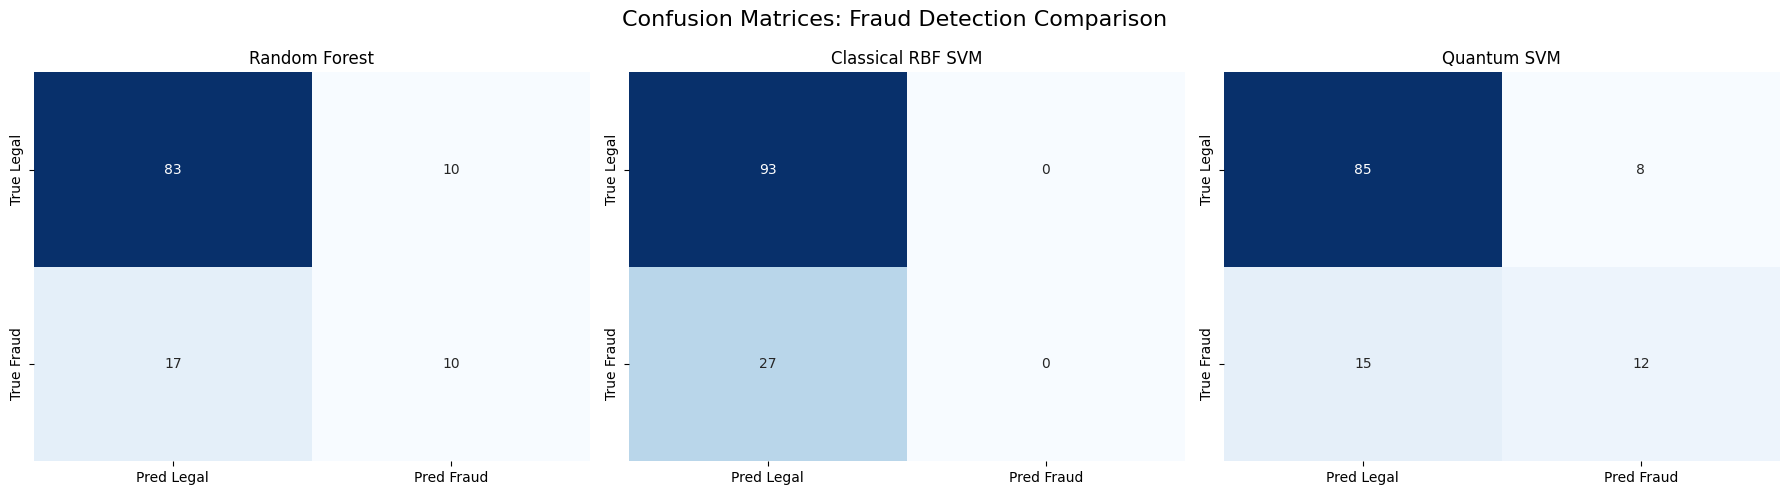

In [52]:
# Confusion Matrix
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

models_preds =[rf_preds, svm_preds, qsvm_iqp_preds]
titles =['Random Forest', 'Classical RBF SVM', 'Quantum SVM']

for i, ax in enumerate(axes):
    cm = confusion_matrix(y_test, models_preds[i])
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax, cbar=False,
                xticklabels=['Pred Legal', 'Pred Fraud'],
                yticklabels=['True Legal', 'True Fraud'])
    ax.set_title(titles[i])

plt.suptitle("Confusion Matrices: Fraud Detection Comparison", fontsize=16)
plt.tight_layout()
plt.show()

Here we can see that the Classical SVM always predicts the transactions as legals. Having a nice global accuracy but a horrible precision in the fraud class.

On the other hand, both Random Forest and Quantum SVM have some tendency to predict frauds as legals, this is normal because the 80% of the samples are legal. 

We can interpret that Quantum SVM is slightly better than Random Forest predicting both legal and fraud cases. Nevertheless, the resources and time needed to create and train the quantum model were higher.